# Import needed modules

In [2]:
# Download the dataset directly into Colab
import kagglehub
path = kagglehub.dataset_download("mahdinavaei/blood-cancer")
print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'blood-cancer' dataset.
Dataset downloaded to: /kaggle/input/blood-cancer


In [3]:
# import system libs
import os
import time
import shutil
import pathlib
import itertools
from PIL import Image

# import data handling tools
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# import Deep learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

print ('modules loaded')

modules loaded


# **Data Preprocessing**

### **Read data and store it in dataframe**

In [4]:
import os
data_dir = os.path.join(path, 'bloodcells_dataset')
filepaths = []
labels = []

folds = os.listdir(data_dir)
for fold in folds:
    foldpath = os.path.join(data_dir, fold)
    filelist = os.listdir(foldpath)
    if fold in ['ig', 'neutrophil']:
        continue
    for file in filelist:
        fpath = os.path.join(foldpath, file)

        filepaths.append(fpath)
        labels.append(fold)

# Concatenate data paths with labels into one dataframe
Fseries = pd.Series(filepaths, name= 'filepaths')
Lseries = pd.Series(labels, name='labels')
df = pd.concat([Fseries, Lseries], axis= 1)

In [5]:
df

,filepaths,labels
0,/kaggle/input/blood-cancer/bloodcells_dataset/...,monocyte
1,/kaggle/input/blood-cancer/bloodcells_dataset/...,monocyte
2,/kaggle/input/blood-cancer/bloodcells_dataset/...,monocyte
3,/kaggle/input/blood-cancer/bloodcells_dataset/...,monocyte
4,/kaggle/input/blood-cancer/bloodcells_dataset/...,monocyte
...,...,...
10863,/kaggle/input/blood-cancer/bloodcells_dataset/...,platelet
10864,/kaggle/input/blood-cancer/bloodcells_dataset/...,platelet
10865,/kaggle/input/blood-cancer/bloodcells_dataset/...,platelet
10866,/kaggle/input/blood-cancer/bloodcells_dataset/...,platelet


### **Split dataframe into train, valid, and test**

In [6]:
# train dataframe
train_df, dummy_df = train_test_split(df,  train_size= 0.8, shuffle= True, random_state= 123)

# valid and test dataframe
valid_df, test_df = train_test_split(dummy_df,  train_size= 0.6, shuffle= True, random_state= 123)

### **Create image data generator**

In [7]:
# crobed image size
batch_size = 16
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

tr_gen = ImageDataGenerator()
ts_gen = ImageDataGenerator()

train_gen = tr_gen.flow_from_dataframe( train_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

valid_gen = ts_gen.flow_from_dataframe( valid_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

test_gen = ts_gen.flow_from_dataframe( test_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= False, batch_size= batch_size)

Found 8694 validated image filenames belonging to 6 classes.
Found 1304 validated image filenames belonging to 6 classes.
Found 870 validated image filenames belonging to 6 classes.


### **Show sample from train data**

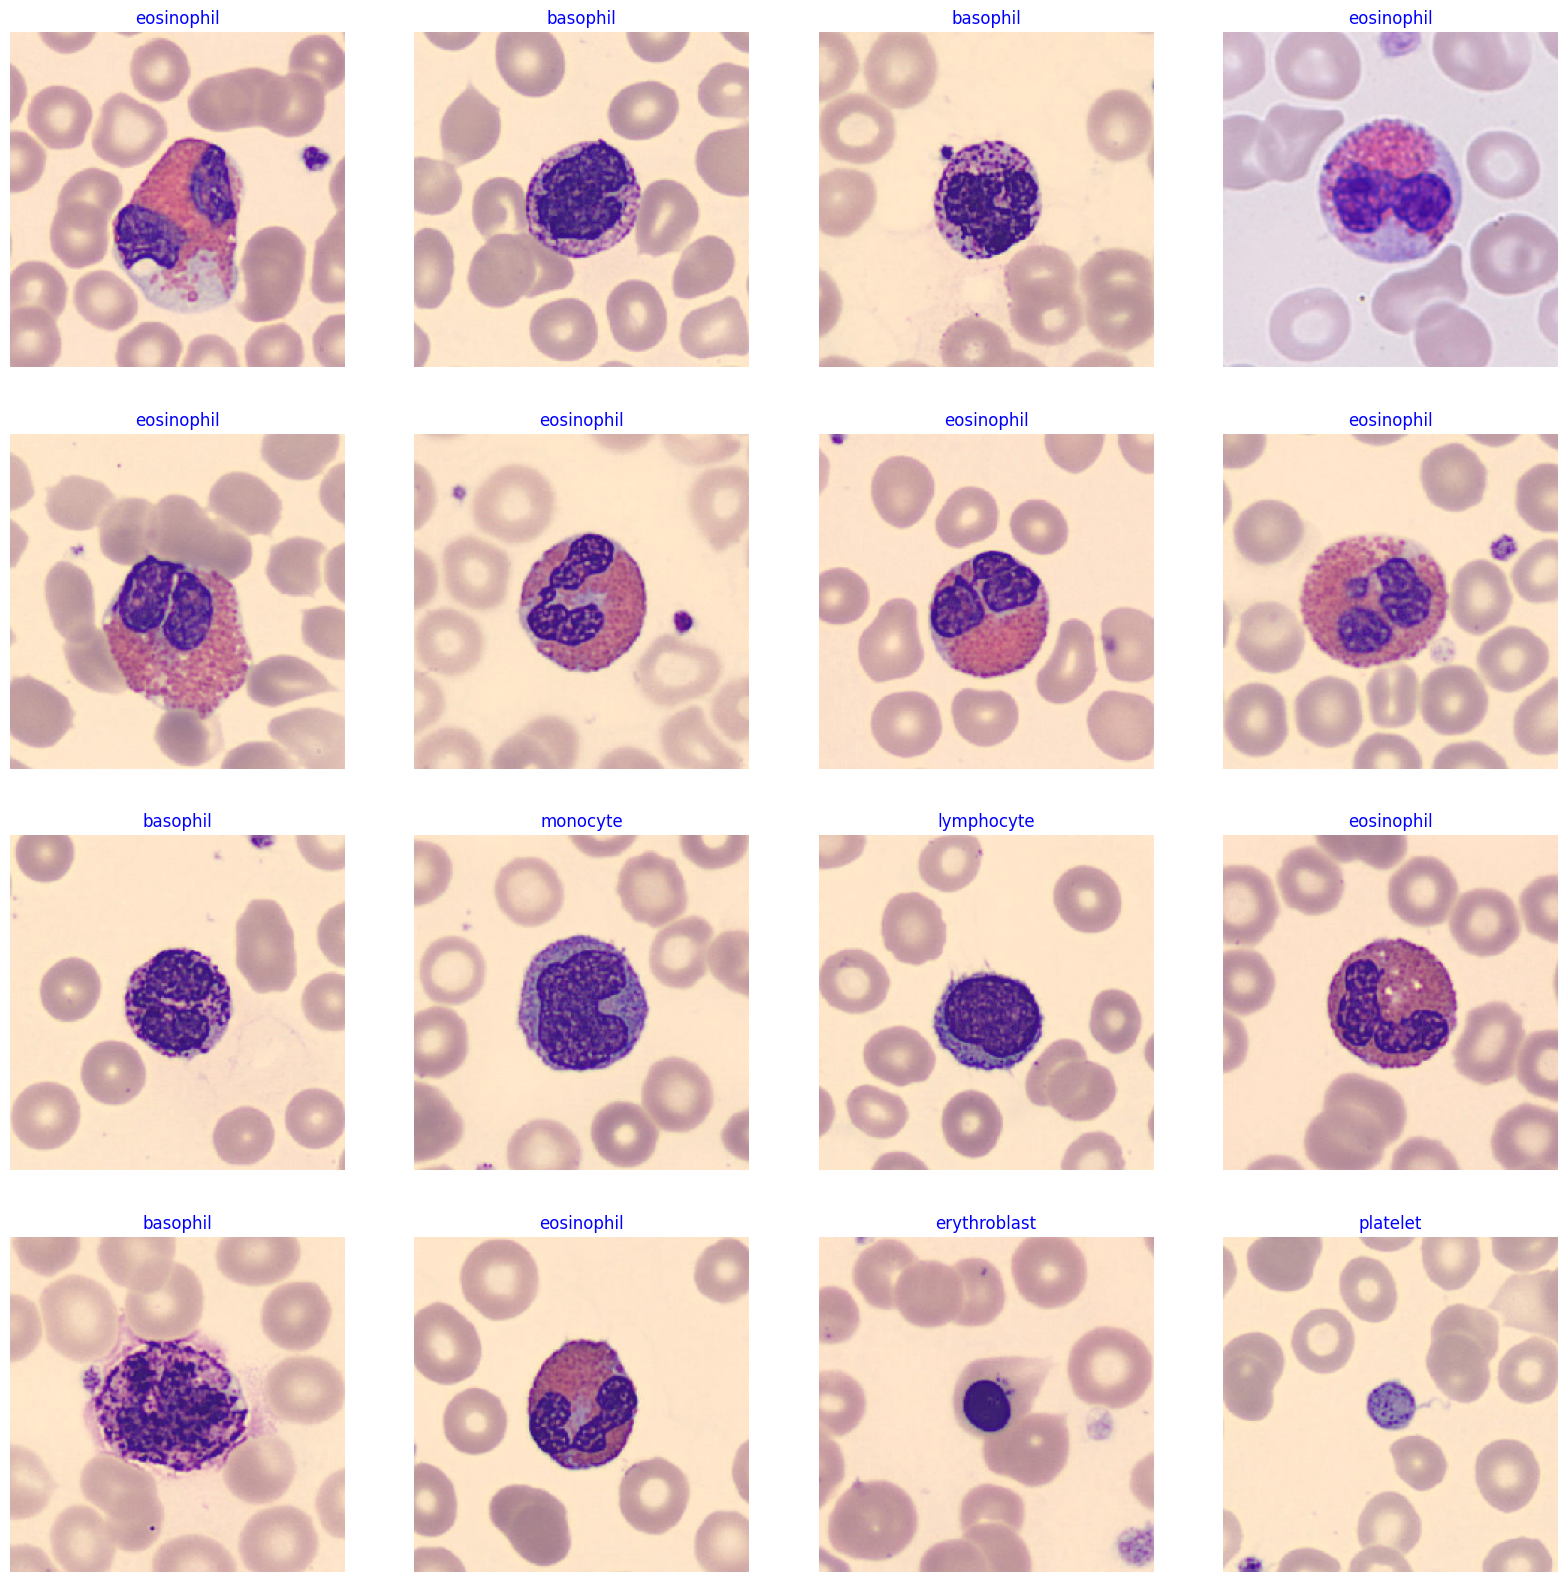

In [8]:
g_dict = train_gen.class_indices      # defines dictionary {'class': index}
classes = list(g_dict.keys())       # defines list of dictionary's kays (classes), classes names : string
images, labels = next(train_gen)      # get a batch size samples from the generator

plt.figure(figsize= (20, 20))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    image = images[i] / 255       # scales data to range (0 - 255)
    plt.imshow(image)
    index = np.argmax(labels[i])  # get image index
    class_name = classes[index]   # get class of image
    plt.title(class_name, color= 'blue', fontsize= 12)
    plt.axis('off')
plt.show()

# **Model Structure**

#### **Generic Model Creation**

In [9]:
# Create Model Structure
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
class_count = len(list(train_gen.class_indices.keys())) # to define number of classes in dense layer

# create pre-trained model (you can built on pretrained model such as :  efficientnet, VGG , Resnet )
# we will use efficientnetb3 from EfficientNet family.
base_model = tf.keras.applications.efficientnet.EfficientNetB3(include_top= False, weights= "imagenet", input_shape= img_shape, pooling= 'max')
base_model.trainable = False

model = Sequential([
    base_model,
    BatchNormalization(axis= -1, momentum= 0.99, epsilon= 0.001),
    Dense(256, kernel_regularizer= regularizers.l2( 0.016), activity_regularizer= regularizers.l1(0.006),
                bias_regularizer= regularizers.l1(0.006), activation= 'relu'),
    Dropout(rate= 0.45, seed= 123),
    Dense(class_count, activation= 'softmax')
])

model.compile(Adamax(learning_rate= 0.001), loss= 'categorical_crossentropy', metrics= ['accuracy'])

model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)     │ (None, 1536)           │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,184,693 (42.67 MB)

 Trainable params: 398,086 (1.52 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

#### **Train model**

In [10]:
epochs = 10   # number of all epochs in training

history = model.fit(x= train_gen, epochs= epochs, verbose= 1, validation_data= valid_gen,
                    validation_steps= None, shuffle= False)

Epoch 1/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 171s 226ms/step - accuracy: 0.6810 - loss: 8.1937 - val_accuracy: 0.8006 - val_loss: 4.6235
Epoch 2/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 36s 67ms/step - accuracy: 0.7376 - loss: 3.4507 - val_accuracy: 0.9034 - val_loss: 2.2423
Epoch 3/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 38s 70ms/step - accuracy: 0.7733 - loss: 1.9008 - val_accuracy: 0.9248 - val_loss: 1.2826
Epoch 4/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 41s 75ms/step - accuracy: 0.7918 - loss: 1.3553 - val_accuracy: 0.9325 - val_loss: 0.9933
Epoch 5/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 41s 76ms/step - accuracy: 0.8079 - loss: 1.1771 - val_accuracy: 0.9494 - val_loss: 0.8615
Epoch 6/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 40s 74ms/step - accuracy: 0.8144 - loss: 1.0973 - val_accuracy: 0.9479 - val_loss: 0.7937
Epoch 7/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 41s 75ms/step - accuracy: 0.8216 - loss: 1.0376 - val_accuracy: 0.9509 - val_loss: 0.7381
Epoch 8/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 42s 77ms/step - accuracy: 0.8270 - loss: 0.9959 

#### **Display model performance**

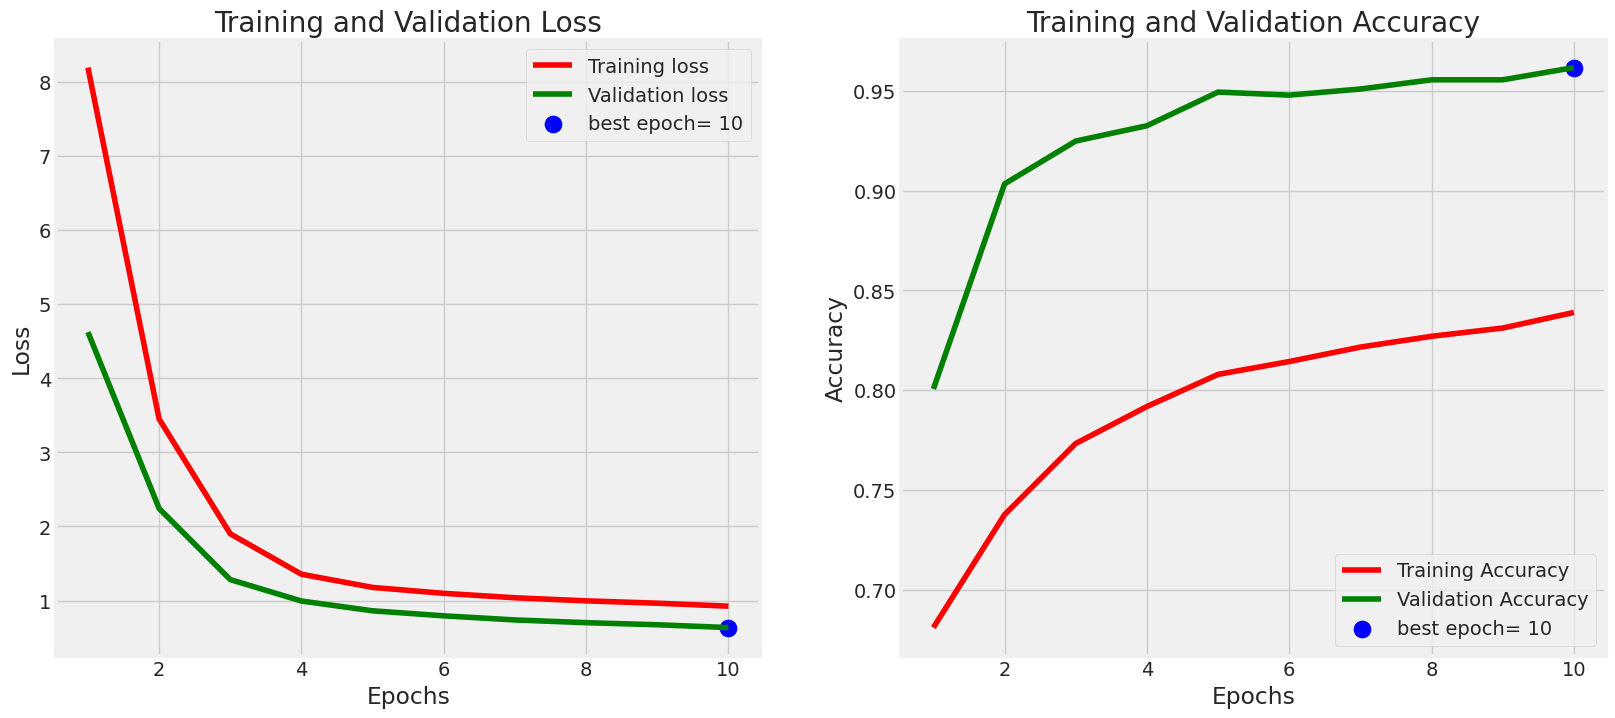

In [11]:
# Define needed variables
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

# **Evaluate model**

In [12]:
ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_gen, steps= test_steps, verbose= 1)
valid_score = model.evaluate(valid_gen, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_gen, steps= test_steps, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.9792 - loss: 0.5986
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.9667 - loss: 0.6232
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - accuracy: 0.9750 - loss: 0.6485
Train Loss:  0.5985555052757263
Train Accuracy:  0.9791666865348816
--------------------
Validation Loss:  0.6231566667556763
Validation Accuracy:  0.9666666388511658
--------------------
Test Loss:  0.6484640836715698
Test Accuracy:  0.9750000238418579


# **Get Predictions**

In [14]:
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)

55/55 ━━━━━━━━━━━━━━━━━━━━ 31s 293ms/step


#### **Confusion Matrics and Classification Report**

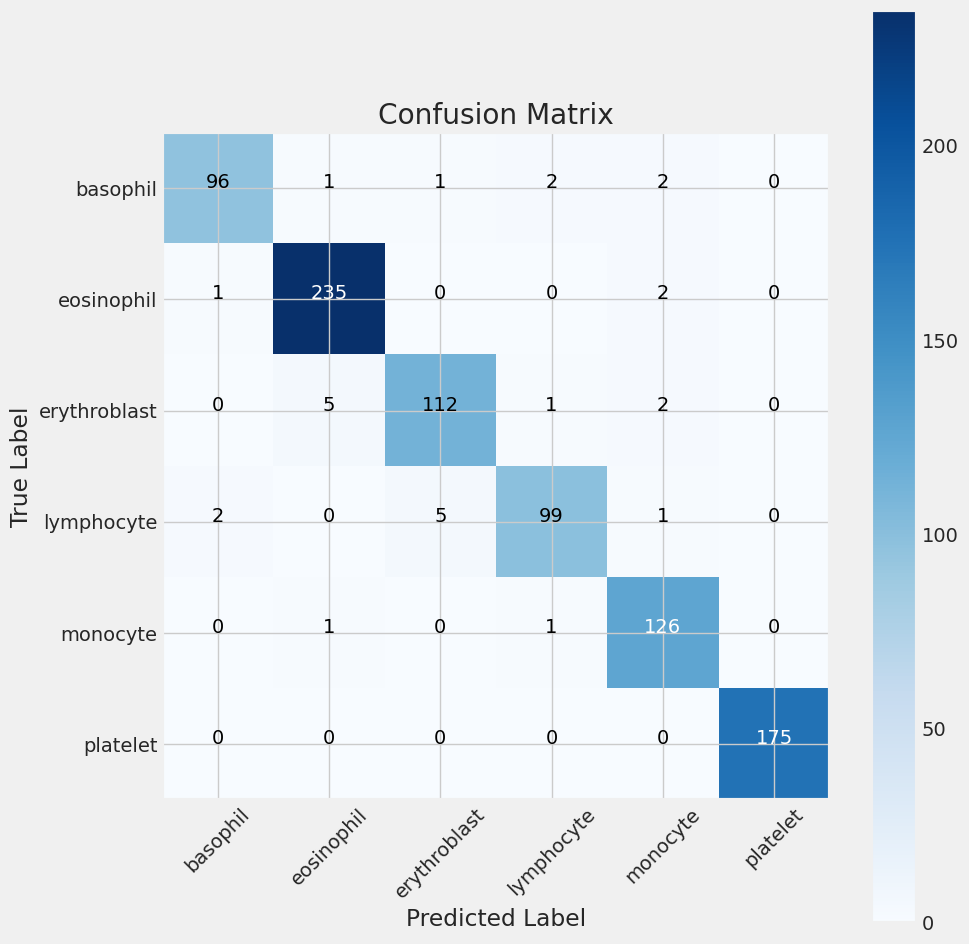

In [15]:
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)


thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [16]:
# Classification report
print(classification_report(test_gen.classes, y_pred, target_names= classes))

              precision    recall  f1-score   support

    basophil       0.97      0.94      0.96       102
  eosinophil       0.97      0.99      0.98       238
erythroblast       0.95      0.93      0.94       120
  lymphocyte       0.96      0.93      0.94       107
    monocyte       0.95      0.98      0.97       128
    platelet       1.00      1.00      1.00       175

    accuracy                           0.97       870
   macro avg       0.97      0.96      0.96       870
weighted avg       0.97      0.97      0.97       870



#### **Save model**

In [17]:
#Save the model
model.save('Bloods.h5')

Please upload an image:


Saving LY_29912.jpg to LY_29912.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step


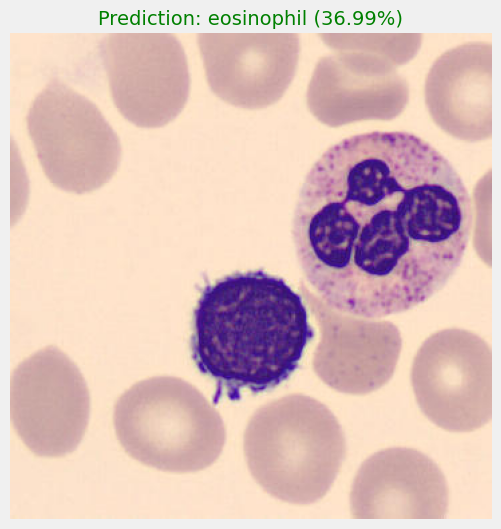


Result: This cell is identified as 'eosinophil' with 36.99% confidence.


In [18]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Upload your new picture from your computer
print("Please upload an image:")
uploaded = files.upload()
image_filename = list(uploaded.keys())[0]

# 2. Preprocess the image to match the model's input size (224x224)
img = cv2.imread(image_filename)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img, (224, 224))
img_array = np.expand_dims(img_resized, axis=0)  # Shape: (1, 224, 224, 3)

# 3. Predict using the trained model
predictions = model.predict(img_array)
predicted_class_index = np.argmax(predictions, axis=1)[0]
confidence = np.max(predictions) * 100

# 4. Map index to class label name
class_labels = list(train_gen.class_indices.keys())
predicted_label = class_labels[predicted_class_index]

# 5. Display the image with the prediction
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.title(f"Prediction: {predicted_label} ({confidence:.2f}%)", fontsize=14, color='green')
plt.show()

print(f"\nResult: This cell is identified as '{predicted_label}' with {confidence:.2f}% confidence.")

Please upload an image:


Saving LY_299340.jpg to LY_299340 (1).jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


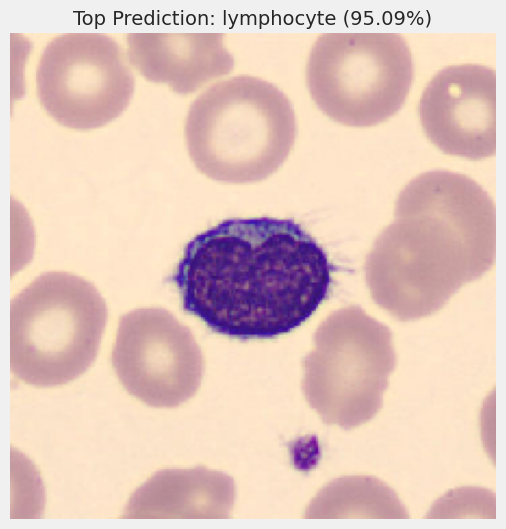


--- Model Confidence for all classes ---
lymphocyte     :  95.09%
erythroblast   :   1.16%
basophil       :   1.08%
monocyte       :   1.05%
eosinophil     :   0.82%
platelet       :   0.81%


In [24]:
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# 1. Upload picture
print("Please upload an image:")
uploaded = files.upload()
image_filename = list(uploaded.keys())[0]

# 2. Load with Keras (exact same way the model was trained)
img = tf.keras.utils.load_img(image_filename, target_size=(224, 224))
img_array = tf.keras.utils.img_to_array(img)
img_batch = np.expand_dims(img_array, axis=0)

# 3. Predict
predictions = model.predict(img_batch)[0]

# 4. Get class labels
class_labels = list(train_gen.class_indices.keys())

# 5. Display image
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
best_idx = np.argmax(predictions)
plt.title(f"Top Prediction: {class_labels[best_idx]} ({predictions[best_idx]*100:.2f}%)", fontsize=14)
plt.show()

# 6. Print all probabilities
print("\n--- Model Confidence for all classes ---")
for label, prob in sorted(zip(class_labels, predictions), key=lambda x: x[1], reverse=True):
    print(f"{label:15s}: {prob*100:6.2f}%")

In [23]:
# 1. Unfreeze the base model so it learns medical microscopic details
base_model.trainable = True

# 2. Re-compile with a small learning rate (to protect existing weights)
model.compile(
    optimizer=tf.keras.optimizers.Adamax(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Starting Fine-Tuning...")
# 3. Train for 5 more epochs on your Colab T4 GPU (takes only ~2 minutes)
history_fine = model.fit(
    x=train_gen,
    epochs=5,
    validation_data=valid_gen,
    verbose=1
)

# 4. Save the upgraded high-confidence model
model.save('Bloods_High_Confidence.h5')
print("Model fine-tuned and saved successfully!")

Starting Fine-Tuning...
Epoch 1/5
544/544 ━━━━━━━━━━━━━━━━━━━━ 290s 313ms/step - accuracy: 0.4683 - loss: 1.5925 - val_accuracy: 0.6595 - val_loss: 1.2680
Epoch 2/5
544/544 ━━━━━━━━━━━━━━━━━━━━ 86s 158ms/step - accuracy: 0.6331 - loss: 1.2949 - val_accuracy: 0.7968 - val_loss: 1.0056
Epoch 3/5
544/544 ━━━━━━━━━━━━━━━━━━━━ 85s 156ms/step - accuracy: 0.7250 - loss: 1.1367 - val_accuracy: 0.8788 - val_loss: 0.8427
Epoch 4/5
544/544 ━━━━━━━━━━━━━━━━━━━━ 86s 157ms/step - accuracy: 0.7746 - loss: 1.0475 - val_accuracy: 0.9057 - val_loss: 0.7650
Epoch 5/5
544/544 ━━━━━━━━━━━━━━━━━━━━ 86s 157ms/step - accuracy: 0.8091 - loss: 0.9758 - val_accuracy: 0.9248 - val_loss: 0.7241


Model fine-tuned and saved successfully!
